# Pipeline Demo

This short notebook demonstrates that the preprocessing pipeline works correctly.
It loads the saved pipeline and processed outputs from `preprocessing_pipeline.ipynb`,
runs a quick model comparison to confirm the data is model-ready, and shows how to
apply the pipeline to new (unseen) data.

**This is not the modeling notebook.** It is a verification step.

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline

output_dir = Path.cwd().parent / "data" / "processed"
print(f"Loading from: {output_dir}")

Loading from: /Users/aklima/GitHub/summer26-wnba-player-valuation/data/processed


## 1. Load Pipeline Outputs

In [2]:
# Load the fitted preprocessor
preprocessor = joblib.load(output_dir / "preprocessor.pkl")

# Load the processed feature matrix and target
X = pd.read_csv(output_dir / "X_processed.csv")
y = pd.read_csv(output_dir / "y_salary.csv")["salary"]

feature_names = pd.read_csv(output_dir / "feature_names.csv")["feature"].tolist()

print(f"X shape:  {X.shape}")
print(f"y shape:  {y.shape}")
print(f"Features: {len(feature_names)}")
print(f"NaNs in X: {X.isna().sum().sum()}")
print(f"NaNs in y: {y.isna().sum()}")

X shape:  (224, 22)
y shape:  (224,)
Features: 22
NaNs in X: 0
NaNs in y: 0


## 2. Quick Smoke Test: Can Models Learn from This Data?

Run 5-fold cross-validation with three models to confirm the pipeline output is learnable.
The only goal here is to check that RMSE beats the dummy baseline — not to tune models.

In [3]:
cv = KFold(n_splits=5, shuffle=True, random_state=26)

models = {
    "DummyRegressor (baseline)": DummyRegressor(strategy="mean"),
    "Ridge Regression":          Ridge(alpha=1.0),
    "Random Forest":              RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=26),
}

rows = []
for name, model in models.items():
    scores = cross_val_score(model, X, y,
                             cv=cv,
                             scoring="neg_root_mean_squared_error")
    rmse_scores = -scores
    rows.append({
        "Model": name,
        "Mean RMSE ($)": f"{rmse_scores.mean():,.0f}",
        "Std RMSE ($)":  f"{rmse_scores.std():,.0f}",
    })

results_df = pd.DataFrame(rows)
print("\nCross-validation results (lower RMSE is better):")
print(results_df.to_string(index=False))


Cross-validation results (lower RMSE is better):
                    Model Mean RMSE ($) Std RMSE ($)
DummyRegressor (baseline)        68,737        2,470
         Ridge Regression        44,833        3,055
            Random Forest        40,166        6,024


## 3. Apply Pipeline to Unseen Data

Demonstration of how to use the pipeline on a new row of raw data.
This is the pattern any modeling notebook should follow for prediction.

In [4]:
# Load the full model-ready dataframe (pre-engineering, pre-pipeline)
model_df = pd.read_csv(output_dir / "model_ready.csv")

# Recover the feature column list (same as feature_cols in the main pipeline notebook)
# We use the pre-OHE names because that's what the ColumnTransformer expects as input
feature_cols_raw = (
    preprocessor.transformers_[0][2]  # numeric feature names
    + preprocessor.transformers_[1][2]  # categorical feature names
)

# Simulate 2 new players (using last 2 rows as a stand-in)
new_players = model_df[feature_cols_raw].tail(2).copy()

# Transform with the fitted pipeline (no re-fitting)
new_X = preprocessor.transform(new_players)

print(f"Input shape:  {new_players.shape}")
print(f"Output shape: {new_X.shape}")
print("Pipeline successfully applied to new data.")

Input shape:  (2, 18)
Output shape: (2, 22)
Pipeline successfully applied to new data.


## 4. Feature Distribution Check

Visual confirmation that numeric features are properly scaled.

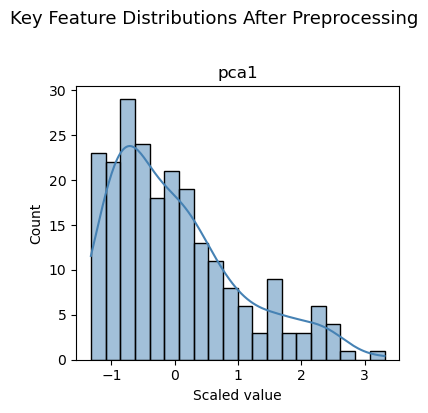

In [6]:
# Plot distributions of a selection of key numeric features after scaling
key_features = [f for f in ["ws", "pts_per_g", "mp_per_g", "pca1", "pts40", "team_power"]
                if f in X.columns]

fig, axes = plt.subplots(1, len(key_features), figsize=(4 * len(key_features), 4))
if len(key_features) == 1:
    axes = [axes]

for ax, feat in zip(axes, key_features):
    sns.histplot(X[feat], kde=True, ax=ax, color="steelblue", bins=20)
    ax.set_title(feat)
    ax.set_xlabel("Scaled value")

plt.suptitle("Key Feature Distributions After Preprocessing", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()